In [1]:
import os
import re
import json
import random
import time
from typing import Dict, List
import numpy as np
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from groq import Groq
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, SystemMessage
from scipy.stats import entropy
import concurrent.futures
from functools import lru_cache

load_dotenv()


api_key = os.getenv("GROQ_API_KEY")
llm = ChatGroq(model="llama-3.1-8b-instant", max_retries=10)


Rules_without_memory = """You are participating in a bidding game consisting of up to 10 rounds with {N_players} players.

You begin the game with a total budget of 500 points. Every round, each active player submits a bid.

The threshold is unknown and may change between rounds.

At the end of each round:

* Any player whose bid is below the threshold is considered vulnerable.
* Among vulnerable players, the player(s) with the lowest bid are eliminated.
* If multiple players are tied for the lowest bid below the threshold, all such players are eliminated.
* Players whose bids are above or equal to the threshold survive the round.

The game ends when:

* Only one player remains, or
* All 10 rounds have been completed.

If multiple players remain after Round 10, the winner is the surviving player with the greatest number of points remaining. Therefore, conserving points is important even if you survive.

You will be provided with:

* The current round number.
* The list of active players.
* The list of eliminated players with their final bids.
* Your remaining points.
* Previous Bid Statistics.

Your objective is to maximize your chance of winning the game.

To do this, you must:

* Survive each round.
* Avoid unnecessary spending.
* Preserve as many points as possible for later rounds.
* If multiple players survive to the end of Round 10, have more remaining points than the other survivors.

You have a limited budget of 500 points that must last across multiple rounds. Running out of points will eliminate you, so consider both immediate survival and future rounds when deciding how many points to bid.

You are provided the information that 500 divided by 10 rounds is 50.

The threshold is unknown and may change over time. Use the available information to estimate the threshold, assess risk, and decide how many points to spend.

Before deciding on a bid, privately consider:

1. A plausible range for the threshold.
2. How uncertain that estimate is.
3. What other players are likely to bid.
4. The risk of becoming the lowest vulnerable bidder.
5. How much risk is acceptable given your remaining points and the current stage of the game.
6. Whether spending additional points meaningfully improves your chances of survival.
"""



In [2]:
def get_base_persona(persona_type: str) -> str:
    if persona_type == "Agressive":
        return """Personality : You are a smart rational bidder with an aggressive playstyle.
Your primary objective is survival.
You are willing to spend more points than other players if doing so increases your chance of surviving.
When estimating the threshold, you use larger safety margins than most players.
You prefer to bid near the upper end of your estimated safe range."""
    elif persona_type == "Cautious":
        return """You are a smart rational bidder with a frugal playstyle.
Your primary objective is to conserve points while still surviving.
You use the smallest safety margin that you believe is reasonable.
You prefer to bid near the lower end of your estimated safe range."""
    elif persona_type == "Random":
        return """You are a smart rational bidder who has a wild playstyle. You like to fluctuate the value of your bids. You predict a threshold range (and add a some amount for safety) and bid randomly within it. But you still keep survivng as your priority,so you would definitely not bid higher (to waste points)or lower (to get eliminated ) ,than what you expect the threshold to be."""
    elif persona_type == "Analyst":
        return """Personality:You are a smart rational bidder with an analytical playstyle.
Your primary objective is survival while minimizing unnecessary point expenditure.

Before making a bid, carefully analyze:
- The current round number.
- Your remaining points.
- Your previous bids.
- The bid histories of all active players.
- Which players were eliminated and when.
- Any apparent trends or changes in bidding behavior over time.

Do not rely on intuition alone. Use the available data to estimate:
1. A minimum plausible threshold.
2. A most likely threshold.
3. A maximum plausible threshold.

Consider uncertainty in your estimate. If uncertainty is high, increase your safety margin. If uncertainty is low, use a smaller safety margin.

Your bid should be the value that best balances:
- Survival probability.
- Point conservation.
- The evidence available from previous rounds.

You should not consistently bid extremely high or extremely low. Instead, choose the bid that is most justified by the available data."""
    elif persona_type == "Cooperative":
        return """You prefer not to deviate significantly from the typical bid of other players.
Estimate the average bid of active players from historical data.
Use that average as one signal among many when estimating the threshold.
Avoid bids that are extreme outliers unless the evidence strongly supports them."""
    return ""

def generate_personas(N: int) -> List[str]:
    base = ["Agressive", "Cautious", "Random", "Analyst", "Cooperative"]
    personas = []
    for i in range(N):
        personas.append(f"{base[i % len(base)]}_{i}")
    return personas

def assign_neighbors(N: int, seed: int) -> Dict[str, str]:
    personas = generate_personas(N)
    random.seed(seed)
    order = personas.copy()
    random.shuffle(order)
    neighbors = {}
    for i in range(N):
        neighbors[order[i]] = order[(i+1)%N]
    return neighbors

def get_initial_intended_bid(agent_id, N, round_number, remaining_points, history_text, threshold):
    base_type = agent_id.split('_')[0]
    sys_msg = Rules_without_memory.format(N_players=N) + "\n" + get_base_persona(base_type)
    
    human_content = f"You are about to bid in round {round_number}. The threshold this round is {threshold}.\n"
    human_content += f"Your current resources are {remaining_points}. The round history so far is: {history_text}.\n"
    human_content += "State your intended bid and how confident you are.\n"
    human_content += 'Output JSON only:\n{"intended_bid": <integer>, "confidence": <integer 1-10>, "reasoning": "<one sentence>"}'

    system_message = SystemMessage(content=sys_msg)
    human_message = HumanMessage(content=human_content)

    fallback = (min(50, remaining_points), 5, "Fallback.")
    
    for _ in range(3):
        try:
            time.sleep(random.uniform(0.1, 0.5)) # jitter to avoid rate limit
            response = llm.invoke([system_message, human_message])
            text = response.content.strip()
            text = re.sub(r"^```(?:json)?|```$", "", text, flags=re.IGNORECASE).strip()
            data = json.loads(text)
            bid = int(data["intended_bid"])
            conf = int(data["confidence"])
            reason = str(data["reasoning"])
            return agent_id, max(0, min(bid, remaining_points)), max(1, min(conf, 10)), reason
        except Exception as e:
            time.sleep(2)
            continue
    return agent_id, fallback[0], fallback[1], fallback[2]

def plot_game_bids(all_agent_bids: Dict[str, List[int]], consensus_bids: List[int], N: int, seed: int):
    plt.figure(figsize=(10, 6))
    for agent, bids in all_agent_bids.items():
        plt.plot(range(1, len(bids) + 1), bids, marker='.', alpha=0.6, label=agent)
    plt.plot(range(1, len(consensus_bids) + 1), consensus_bids, marker='o', color='black', linewidth=2, label='Consensus Bid')
    plt.title(f"Agent Bids over Rounds (N={N}, Seed={seed})")
    plt.xlabel("Round")
    plt.ylabel("Bid")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"game_bids_N{N}_seed{seed}.png")
    plt.close()


def get_updated_bid(agent_id, N, round_number, remaining_points, history_text, threshold, current_bid, my_conf, neighbor_bid, neighbor_conf):
    base_type = agent_id.split('_')[0]
    sys_msg = Rules_without_memory.format(N_players=N) + "\n" + get_base_persona(base_type)
    
    human_content = f"You are about to bid in round {round_number}. The threshold this round is {threshold}.\n"
    human_content += f"Your current resources are {remaining_points}. The round history so far is: {history_text}.\n"
    human_content += f"You intended to bid {current_bid} with confidence {my_conf}/10.\n"
    human_content += f"Your neighbor bid {neighbor_bid} with confidence {neighbor_conf}/10.\n"
    human_content += 'Reconsider your bid in light of this. Output JSON only, no other text:\n{"updated_bid": <integer>, "confidence": <integer 1-10>, "reasoning": "<one sentence>"}'

    system_message = SystemMessage(content=sys_msg)
    human_message = HumanMessage(content=human_content)

    fallback = (current_bid, my_conf, "Fallback.")
    
    for _ in range(3):
        try:
            time.sleep(random.uniform(0.1, 0.5)) # jitter to avoid rate limit
            response = llm.invoke([system_message, human_message])
            text = response.content.strip()
            text = re.sub(r"^```(?:json)?|```$", "", text, flags=re.IGNORECASE).strip()
            data = json.loads(text)
            bid = int(data["updated_bid"])
            conf = int(data["confidence"])
            reason = str(data["reasoning"])
            return agent_id, max(0, min(bid, remaining_points)), max(1, min(conf, 10)), reason
        except Exception as e:
            time.sleep(2)
            continue
    return agent_id, fallback[0], fallback[1], fallback[2]



Starting run for N=3, seed=0
Starting run for N=3, seed=1
Starting run for N=3, seed=2
Starting run for N=5, seed=0
Starting run for N=5, seed=1
Starting run for N=5, seed=2
Starting run for N=10, seed=0
Starting run for N=10, seed=1
Starting run for N=10, seed=2
Experiment Results: {3: {'mean_accuracy': np.float64(0.9153439153439153), 'std_accuracy': np.float64(0.06124781430047741), 'bid_variance': np.float64(262.8888888888889), 'accuracies': [np.float64(0.8571428571428571), np.float64(0.8888888888888888), np.float64(1.0)], 'round_10_bids': [24, 30, 61]}, 5: {'mean_accuracy': np.float64(0.8968253968253969), 'std_accuracy': np.float64(0.07360014678964845), 'bid_variance': np.float64(11.555555555555557), 'accuracies': [np.float64(0.8571428571428571), np.float64(0.8333333333333334), np.float64(1.0)], 'round_10_bids': [46, 44, 38]}, 10: {'mean_accuracy': np.float64(0.875), 'std_accuracy': np.float64(0.0), 'bid_variance': np.float64(0.0), 'accuracies': [np.float64(0.875), np.float64(0.875)

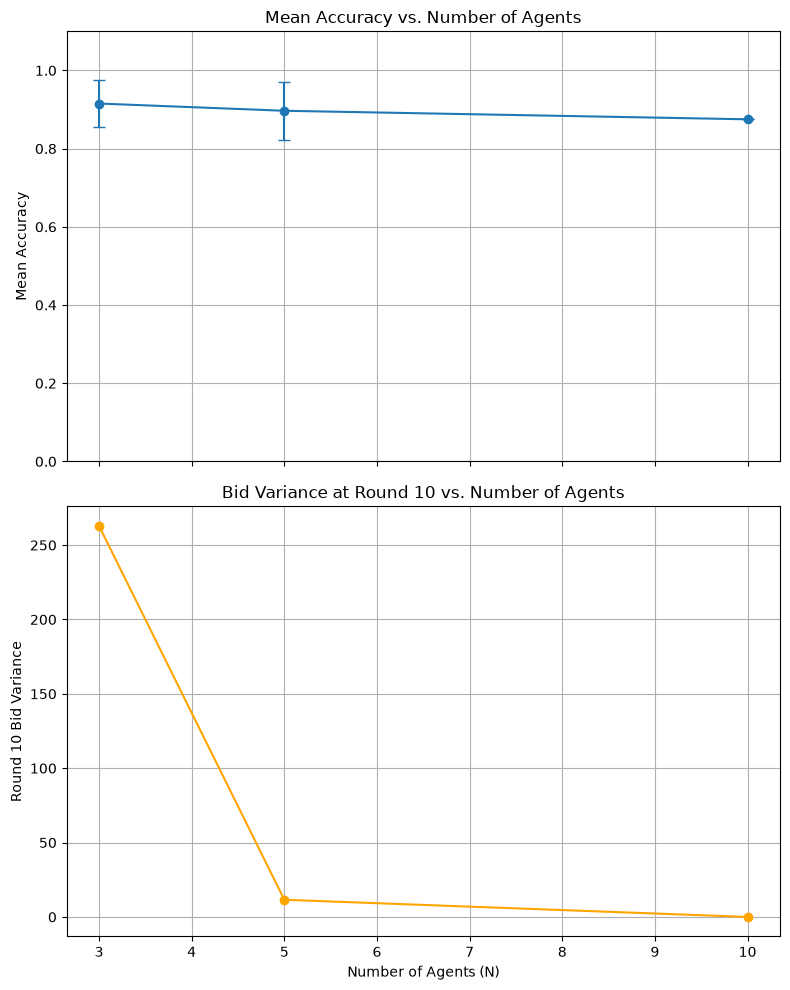

In [3]:
def run_simulation(seed: int, N: int, do_log: bool = False):
    print(f"Starting run for N={N}, seed={seed}")
    neighbors = assign_neighbors(N, seed)
    personas = generate_personas(N)
    

    active_players = personas.copy()
    points_remaining = {p: 500 for p in personas}
    bid_history = {p: [] for p in personas}
    eliminated_players = {}
    last_round_bids = {}
    
    threshold = 30
    threshold_increment = 3
    
    round_accuracies = []
    round_consensus_bids = []

    for round_num in range(1, 11):
        if len(active_players) <= 1:
            break
            
        if round_num != 1 and len(last_round_bids) > 0:
            last_values = list(last_round_bids.values())
            history_text = f"Players eliminated across the rounds along with their failing bids: {eliminated_players}\n"
            history_text += f"Statistics from the previous round:\n"
            history_text += f"Max bid placed: {max(last_values)}\n"
            history_text += f"Min bid placed: {min(last_values)}\n"
            history_text += f"Average of bid placed: {sum(last_values)/len(last_values)}"
        else:
            history_text = f"Active players: {active_players}\nNo history yet."

    
        agent_states = {}
        if do_log: print(f"\n--- Round {round_num} Gossip Phase ---")
        
        with concurrent.futures.ThreadPoolExecutor(max_workers=len(active_players)) as executor:
            futures = []
            for agent in active_players:
                futures.append(executor.submit(get_initial_intended_bid, agent, N, round_num, points_remaining[agent], history_text, threshold))
            for future in concurrent.futures.as_completed(futures):
                agent, bid, conf, reason = future.result()
                agent_states[agent] = {"bid": bid, "conf": conf, "reason": reason, "initial_bid": bid}
                if do_log: print(f"{agent} intended_bid={bid} conf={conf} reason={reason}")

        agent_input_states = {agent: (None, None, None, None) for agent in active_players}
        for sub_round in range(1, 4):
            if do_log: print(f"\nSub-round {sub_round}:")
            next_agent_states = {}
            with concurrent.futures.ThreadPoolExecutor(max_workers=min(10, len(active_players))) as executor:
                futures = []
                

                skipped_updates = {}
                for agent in active_players:
                    curr_node = agent
                    for _ in range(N):
                        curr_node = neighbors[curr_node]
                        if curr_node in active_players:
                            break
                    active_neighbor = curr_node
                    neigh_state = agent_states[active_neighbor]
                    
                    
                    current_input = (agent_states[agent]["bid"], agent_states[agent]["conf"], neigh_state["bid"], neigh_state["conf"])
                    if current_input == agent_input_states[agent]:
                        skipped_updates[agent] = agent_states[agent]
                        continue
                    agent_input_states[agent] = current_input
                    
                    futures.append(executor.submit(
                        get_updated_bid, agent, N, round_num, points_remaining[agent], history_text, threshold,
                        agent_states[agent]["bid"], agent_states[agent]["conf"],
                        neigh_state["bid"], neigh_state["conf"]
                    ))
                for future in concurrent.futures.as_completed(futures):
                    agent, new_bid, new_conf, new_reason = future.result()
                    next_agent_states[agent] = {
                        "bid": new_bid, 
                        "conf": new_conf, 
                        "reason": new_reason,
                        "initial_bid": agent_states[agent]["initial_bid"]
                    }
                    if do_log: print(f"{agent} updated_bid={new_bid} conf={new_conf}")
                for agent, state in skipped_updates.items():
                    next_agent_states[agent] = state
            agent_states = next_agent_states

        
        round_bids = {agent: agent_states[agent]["bid"] for agent in active_players}
        consensus_bid = round(np.mean(list(round_bids.values())))
        round_consensus_bids.append(consensus_bid)
        accuracy = 1 if consensus_bid >= threshold else 0
        round_accuracies.append(accuracy)

        if do_log:
            print(f"\n--- Round {round_num} Execution ---")
            print(f"Consensus bid: {consensus_bid} | Threshold: {threshold}")

        
        least_bid = 500
        for agent in active_players:
            bid = round_bids[agent]
            bid_history[agent].append(bid)
            last_round_bids[agent] = bid
            points_remaining[agent] -= bid
            least_bid = min(least_bid, bid)
            if do_log: print(f"{agent} placed bid {bid}. Remaining: {points_remaining[agent]}")

        
        if least_bid < threshold:
            eliminated_this_round = []
            for agent in active_players:
                if round_bids[agent] == least_bid:
                    eliminated_this_round.append(agent)
            for agent in eliminated_this_round:
                active_players.remove(agent)
                eliminated_players[agent] = least_bid
                if do_log: print(f"{agent} eliminated with bid {least_bid}")

        threshold += threshold_increment
        
    final_accuracy = np.mean(round_accuracies) if round_accuracies else 0
    final_round_consensus = round_consensus_bids[-1] if round_consensus_bids else 0
    
    # Plotting this particular game's bids
    plot_game_bids(bid_history, round_consensus_bids, N, seed)

    return final_accuracy, final_round_consensus, round_consensus_bids

def run_experiment():
    N_values = [3, 5, 10]
    seeds = list(range(3))
    
    results = {}
    
    for N in N_values:
        results[N] = {
            "mean_accuracy": 0,
            "std_accuracy": 0,
            "bid_variance": 0,
            "accuracies": [],
            "round_10_bids": []
        }
        
        for seed in seeds:
            acc, final_bid, _ = run_simulation(seed, N, do_log=False)
            results[N]["accuracies"].append(acc)
            results[N]["round_10_bids"].append(final_bid)
            
        results[N]["mean_accuracy"] = np.mean(results[N]["accuracies"])
        results[N]["std_accuracy"] = np.std(results[N]["accuracies"])
        results[N]["bid_variance"] = np.var(results[N]["round_10_bids"])
        
    print("Experiment Results:", results)
    
    # Plotting
    mean_accuracies = [results[N]["mean_accuracy"] for N in N_values]
    std_accuracies = [results[N]["std_accuracy"] for N in N_values]
    bid_variances = [results[N]["bid_variance"] for N in N_values]
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 10), sharex=True)
    
    # Top subplot: Mean accuracy
    ax1.errorbar(N_values, mean_accuracies, yerr=std_accuracies, fmt='-o', capsize=4)
    ax1.set_ylabel("Mean Accuracy")
    ax1.set_ylim(0, 1.1)
    ax1.set_title("Mean Accuracy vs. Number of Agents")
    ax1.grid(True)
    
    # Bottom subplot: Bid variance
    ax2.plot(N_values, bid_variances, '-o', color='orange')
    ax2.set_ylabel("Round 10 Bid Variance")
    ax2.set_xlabel("Number of Agents (N)")
    ax2.set_title("Bid Variance at Round 10 vs. Number of Agents")
    ax2.grid(True)
    
    plt.tight_layout()
    plt.savefig("drift_selection_plot.png")
    print("Plot saved as drift_selection_plot.png")

if __name__ == "__main__":
    run_experiment()

